#### Import necessary libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
solar_capacity = pd.read_csv("solar/sgu-solar-capacity-2011-to-present.csv")
solar_installation = pd.read_csv("solar/sgu-solar-installations-2011-to-present.csv")
tax_2012 = pd.read_csv(
    "tax-records/tax-2012-postcode.csv",
    header=2,
    low_memory=False
)
tax_2023 = pd.read_csv(
    "tax-records/tax-2023-postcode.csv",
    header=1,
    low_memory=False
)

tax_2012 = tax_2012.drop_duplicates()
tax_2012 = tax_2012.fillna(0)

solar_installation["Small Unit Installation Postcode"] = pd.to_numeric(
    solar_installation["Small Unit Installation Postcode"],
    errors="coerce"
)

vic_solar_installation = solar_installation[
    (
        (solar_installation["Small Unit Installation Postcode"] >= 3000) &
        (solar_installation["Small Unit Installation Postcode"] <= 3999)
    ) |
    (
        (solar_installation["Small Unit Installation Postcode"] >= 8000) &
        (solar_installation["Small Unit Installation Postcode"] <= 8999)
    )
]

vic_solar_installation.to_csv("victoria_installations.csv", index=False)

solar_capacity["Small Unit Installation Postcode"] = pd.to_numeric(
    solar_capacity["Small Unit Installation Postcode"],
    errors="coerce"
)

vic_solar_capacity = solar_capacity[
    (
        (solar_capacity["Small Unit Installation Postcode"] >= 3000) &
        (solar_capacity["Small Unit Installation Postcode"] <= 3999)
    ) |
    (
        (solar_capacity["Small Unit Installation Postcode"] >= 8000) &
        (solar_capacity["Small Unit Installation Postcode"] <= 8999)
    )
]

vic_solar_capacity.to_csv("victoria_capacity.csv", index=False)


tax_2012["Postcode"] = pd.to_numeric(
    tax_2012["Postcode"],
    errors="coerce"
)

tax_small = tax_2012[
    [
        "Postcode",
        "Number of individuals\nno.",
        "Taxable income or loss\n$"
    ]
].copy()

vic_tax_2012 = tax_small[
    (
        (tax_small["Postcode"] >= 3000) &
        (tax_small["Postcode"] <= 3999)
    ) |
    (
        (tax_small["Postcode"] >= 8000) &
        (tax_small["Postcode"] <= 8999)
    )
]

vic_tax_2012.to_csv("2012_victoria_tax.csv", index=False)

tax_2023["Postcode"] = pd.to_numeric(
    tax_2023["Postcode"],
    errors="coerce"
)

tax_small = tax_2023[
    [
        "Postcode",
        "Individuals\nno.",
        "Taxable income or loss4\n$"
    ]
].copy()

vic_tax_2023 = tax_small[
    (
        (tax_small["Postcode"] >= 3000) &
        (tax_small["Postcode"] <= 3999)
    ) |
    (
        (tax_small["Postcode"] >= 8000) &
        (tax_small["Postcode"] <= 8999)
    )
]

vic_tax_2023.to_csv("2023_victoria_tax.csv", index=False)

In [14]:
solar_capacity = pd.read_csv("solar/victoria_capacity.csv")
solar_installation = pd.read_csv("solar/victoria_installations.csv")
melbourne_houses = pd.read_csv("houses/Melbourne_housing_FULL.csv")
tax_2016 = pd.read_csv(
    "tax-records/tax-2016-postcode.csv",
    header=2,
    low_memory=False
)

# Total solar installation 
year_cols_install = [
    col for col in solar_installation.columns
    if any(str(year) in col for year in range(2011, 2024))
]
total_solar_installation = solar_installation[['Small Unit Installation Postcode']].copy()
total_solar_installation['total_installation'] = solar_installation[year_cols_install].sum(axis=1)
total_solar_installation = total_solar_installation.rename(
    columns={'Small Unit Installation Postcode': 'Postcode'}
)

#Total Solar capacity
year_cols_capacity = [
    col for col in solar_capacity.columns
    if any(str(year) in col for year in range(2011, 2024))
]
total_solar_capacity = solar_capacity[['Small Unit Installation Postcode']].copy()
total_solar_capacity['total_capacity'] = solar_capacity[year_cols_capacity].sum(axis=1)
total_solar_capacity = total_solar_capacity.rename(
    columns={'Small Unit Installation Postcode': 'Postcode'}
)

#Average melbourne home price and property count
melbourne_houses['Price'] = pd.to_numeric(melbourne_houses['Price'], errors='coerce')
avg_melbourne_houses = (
    melbourne_houses
        .assign(Price=pd.to_numeric(melbourne_houses['Price'], errors='coerce'))
        .groupby('Postcode')
        .agg(
            Propertycount=('Propertycount', 'first'),
            MedianPrice=('Price', 'median')
        )
        .reset_index()
)

tax_2016["Postcode"] = pd.to_numeric(
    tax_2016["Postcode"],
    errors="coerce"
)

tax_small = tax_2016[
    [
        "Postcode",
        "Number of individuals\nno.",
        "Taxable income or loss3 \n$"
    ]
].copy()

vic_tax_2016 = tax_small[
    (
        (tax_small["Postcode"] >= 3000) &
        (tax_small["Postcode"] <= 3999)
    ) |
    (
        (tax_small["Postcode"] >= 8000) &
        (tax_small["Postcode"] <= 8999)
    )
]

vic_tax_2016.to_csv("2016_victoria_tax.csv", index=False)

main = (
    total_solar_installation
    .merge(total_solar_capacity, on='Postcode')
    .merge(avg_melbourne_houses, on='Postcode')
    .merge(vic_tax_2016, on='Postcode')
)

# Finding average capacity per installation
main["capacity_per_installation"] = (
    main["total_capacity"]
    / main["total_installation"]
)

main = main.rename(
    columns={
        'Number of individuals\nno.': 'Individuals',
        'Taxable income or loss3 \n$': 'Taxable income or loss'
    }
)

#Changing the dataype to become float instead of string
main["Individuals"] = (
    main["Individuals"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

main["Taxable income or loss"] = (
    main["Taxable income or loss"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)

# Average income per person
main["income_per_person"] = (
    main["Taxable income or loss"]
    / main["Individuals"]
)

# Finding the average installation per property
main["installation_per_propety"] = (
    main["total_installation"]
    / main["Propertycount"]
)

main.to_csv("2016_comp_solar.csv", index=False)

features =[
    "installation_per_propety",
    "capacity_per_installation",
    "income_per_person",
    "MedianPrice"
]
# Handle missing values using the median of the other rows
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(main[features])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

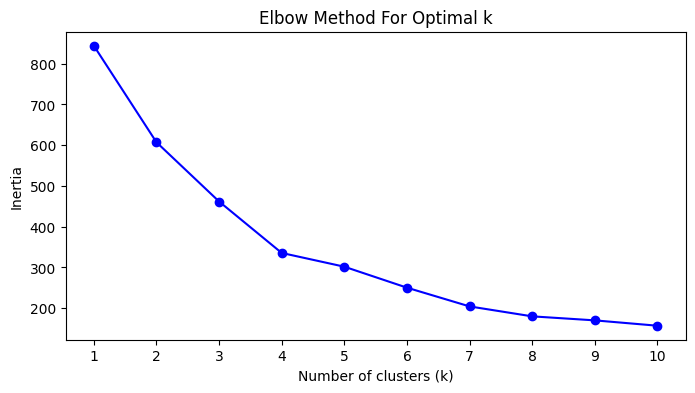

In [15]:
from sklearn.cluster import KMeans

k_values = range(1, 11)
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_values)
plt.show()

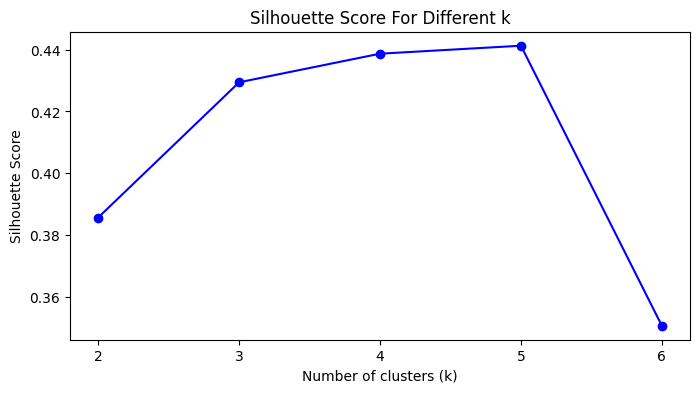

In [16]:
from sklearn.metrics import silhouette_score

k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Different k')
plt.xticks(k_values)
plt.show()

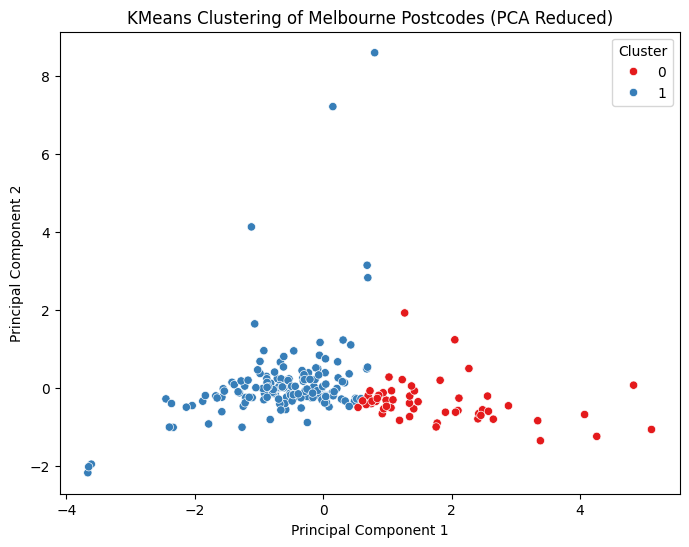

In [6]:
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=5,random_state=42)

kmeans.fit(X_scaled)
main['cluster'] = kmeans.labels_

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

main['pc1'] = principal_components[:, 0]
main['pc2'] = principal_components[:, 1]

# Plot the clusters
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='Set1',
    data=main
)

plt.title('KMeans Clustering of Melbourne Postcodes (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()
